This notebook contains code to generate parameter fits and predicted Q-values for the HMM model

There are two included models:
1. Turn Bias
2. Spatial Bias

The likelihood function is as follows:


Assuming we're at stem 1,
```
QEff1 = βstay * Q(OppositeLeaf) + stay_bias
QEff2 = βgo * QAvg(stem) + spatial_bias[2]
QEff3 = βgo * QAvg(stem)
```
Our stem choice is then predicted by a softmax: $p(a) = \frac{\exp{p(a)}}{\sum_{a'}\exp{p(a')}}$

In the Turn Bias model, all spatial biases are modeled by a single `turn_bias` parameter
In the Spatial Bias model, each stem has a unique spatial bias


In [30]:
# Whether to recompute results
# RERUN = false;
RERUN = true; #AC

In [31]:
# Save Q-values and other meta-information
SAVE_Q = true;

In [32]:
using SpecialFunctions
using Plots
using StatsPlots
using FileIO
using EM
filepath = ".."
include("$(filepath)/code/hmm.jl")
include("$(filepath)/code/util.jl")
include("$(filepath)/code/em_scripts.jl");

In [33]:
# Model we're analyzing in this notebook
fn = "leaf_stay_turn_leafspatial_rewscaled"
println("Model: $(fn)")

Model: leaf_stay_turn_leafspatial_rewscaled


## HMM Q Values

In [34]:
function find_Q_vals_by_day(animal, results; add_leaf=true, rewscaled=true)
    data = load_animal(animal, "..")
    ndays = maximum(data.daynum)
    liks = zeros(ndays)
    dfs = []
    for i in 1:ndays
        (liks[i], df) = hmm_lik(view(data, data.daynum .== i, :), get_contingencies(), results;
            subject=i, add_leaf=add_leaf, rewscaled=rewscaled, record=true)
        push!(dfs, df)
    end
    # Combine all session results
    record_df = vcat(dfs...)
    # Append columns to the original data
    hcat(data, record_df)
end;

In [35]:
#ENV["JULIA_NUM_THREADS"]="20"

In [36]:
ENV["JULIA_NUM_THREADS"]

"20"

## Load Data

In [37]:
results = Dict()
Qs = Dict();
for animal in animals
    if RERUN
        results[animal] = run_hmm_leaf_stay_turn_leafspatial(load_animal(animal, ".."); maxiter=100, extended=true)
        Qs[animal] = find_Q_vals_by_day(animal, results[animal])    
        save("$(filepath)/results/hmm_biases/hmm_$(fn)_$(animal).jld2", "results", results[animal])
    else
        results[animal] = load("$(filepath)/results/hmm_biases/hmm_$(fn)_$(animal).jld2", "hmm_$(fn)_$(animal)")
        Qs[animal] = find_Q_vals_by_day(animal, results[animal])
    end
    if SAVE_Q
        CSV.write("$(filepath)/results/hmm_Q_vals/Q_vals_$(fn)_$(animal).csv", Qs[animal])
    end
end

┌ Info: Running emerrors
└ @ Main /home/alison/Src/SpatialBanditTask/code/hmm.jl:754
┌ Info: Running emerrors
└ @ Main /home/alison/Src/SpatialBanditTask/code/hmm.jl:754
┌ Info: Running emerrors
└ @ Main /home/alison/Src/SpatialBanditTask/code/hmm.jl:754
┌ Info: Running emerrors
└ @ Main /home/alison/Src/SpatialBanditTask/code/hmm.jl:754
┌ Info: Running emerrors
└ @ Main /home/alison/Src/SpatialBanditTask/code/hmm.jl:754


## Show Model Fits

In [8]:
animal = "peanut"
println("$(fn): $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

leaf_stay_turn_leafspatial_rewscaled: peanut
AIC: 3484.99


HTML{String}("<pre>[\"volatility\", \"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"*volatility\"]<br/></pre>β:<br/><pre> volat βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ *vola <br/> <span style='color: red'>-0.75</span>  14.97  12.45  5.15  4.12  <span style='color: red'>-0.76</span>  <span style='color: red'>-0.15</span>  <span style='color: red'>-0.28</span>  <span style='color: red'>-0.29</span>  0.23<br/>p:<br/> 0.01  0.01  0.01  0.03  0.01  0.01  0.32  0.04  0.12</pre>σ²:<br/><pre>  0.04   0.38   0.47   0.21  <span style='color: red'>-0.02</span>   0.04   0.01  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.03</span><br/>  0.38  26.82  19.36   1.11   5.34  <span style='color: red'>-2.47</span>  <span style='color: red'>-0.01</span>  <span style='color: red'>-0.66</span>  <span style='color: red'>-0.89</span><br/>  0.47  19.36  17.53  <span style='color: red'>-2.73</span>   2.51  <span style='color: red'>-1.73</span>   0.35  <span style='color: red'>-0.24</span>  <span style='color: red'>-0.04</span><br/>  0.21   1.11  <span style='color: red'>-2.73</span>  14.13   1.64   1.63  <span style='color: red'>-0.61</span>  <span style='color: red'>-1.52</span>  <span style='color: red'>-2.01</span><br/> <span style='color: red'>-0.02</span>   5.34   2.51   1.64   1.65  <span style='color: red'>-0.51</span>  <span style='color: red'>-0.15</span>  <span style='color: red'>-0.22</span>  <span style='color: red'>-0.43</span><br/>  0.04  <span style='color: red'>-2.47</span>  <span style='color: red'>-1.73</span>   1.63  <span style='color: red'>-0.51</span>   0.57  <span style='color: red'>-0.03</span>  <span style='color: red'>-0.16</span>  <span style='color: red'>-0.13</span><br/>  0.01  <span style='color: red'>-0.01</span>   0.35  <span style='color: red'>-0.61</span>  <span style='color: red'>-0.15</span>  <span style='color: red'>-0.03</span>   0.05   0.06   0.1<br/> <span style='color: red'>-0.04</span>  <span style='color: red'>-0.66</span>  <span style='color: red'>-0.24</span>  <span style='color: red'>-1.52</span>  <span style='color: red'>-0.22</span>  <span style='color: red'>-0.16</span>   0.06   0.2    0.22<br/> <span style='color: red'>-0.03</span>  <span style='color: red'>-0.89</span>  <span style='color: red'>-0.04</span>  <span style='color: red'>-2.01</span>  <span style='color: red'>-0.43</span>  <span style='color: red'>-0.13</span>   0.1    0.22   0.32</pre>")

In [9]:
animal = "senor"
println("$(fn): $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

leaf_stay_turn_leafspatial_rewscaled: senor
AIC: 3230.16


HTML{String}("<pre>[\"volatility\", \"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"*volatility\"]<br/></pre>β:<br/><pre> volat βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ *vola <br/> <span style='color: red'>-0.89</span>  13.78  10.5  2.59  5.14  <span style='color: red'>-0.33</span>  <span style='color: red'>-0.14</span>  <span style='color: red'>-0.22</span>  0.17  0.19<br/>p:<br/> 0.01  0.01  0.01  0.25  0.01  0.35  0.28  0.46  0.03</pre>σ²:<br/><pre>  0.11   1.02   0.54  <span style='color: red'>-0.37</span>   0.13  <span style='color: red'>-0.01</span>   0.06   0.1    0.01<br/>  1.02  34.61   1.36   1.25  12.29  <span style='color: red'>-4.48</span>   0.82   2.15   0.25<br/>  0.54   1.36  12.45   3.47  <span style='color: red'>-4.22</span>  <span style='color: red'>-0.01</span>   0.89   1.27   0.33<br/> <span style='color: red'>-0.37</span>   1.25   3.47  50.64  <span style='color: red'>-1.64</span>  <span style='color: red'>-5.44</span>  <span style='color: red'>-0.35</span>  <span style='color: red'>-4.39</span>   1.64<br/>  0.13  12.29  <span style='color: red'>-4.22</span>  <span style='color: red'>-1.64</span>   6.21  <span style='color: red'>-1.62</span>  <span style='color: red'>-0.04</span>   0.45  <span style='color: red'>-0.07</span><br/> <span style='color: red'>-0.01</span>  <span style='color: red'>-4.48</span>  <span style='color: red'>-0.01</span>  <span style='color: red'>-5.44</span>  <span style='color: red'>-1.62</span>   1.22  <span style='color: red'>-0.03</span>   0.19  <span style='color: red'>-0.18</span><br/>  0.06   0.82   0.89  <span style='color: red'>-0.35</span>  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.03</span>   0.15   0.18   0.02<br/>  0.1    2.15   1.27  <span style='color: red'>-4.39</span>   0.45   0.19   0.18   0.8   <span style='color: red'>-0.12</span><br/>  0.01   0.25   0.33   1.64  <span style='color: red'>-0.07</span>  <span style='color: red'>-0.18</span>   0.02  <span style='color: red'>-0.12</span>   0.06</pre>")

In [10]:
animal = "chimi"
println("$(fn): $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

leaf_stay_turn_leafspatial_rewscaled: chimi
AIC: 2053.47


HTML{String}("<pre>[\"volatility\", \"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"*volatility\"]<br/></pre>β:<br/><pre> volat βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ *vola <br/> <span style='color: red'>-1.02</span>  9.01  6.33  2.86  4.98  <span style='color: red'>-0.24</span>  0.05  0.08  0.02  0.15<br/>p:<br/> 0.01  0.01  0.02  0.46  0.01  0.35  0.5  0.24  0.96</pre>σ²:<br/><pre>  0.03   0.46   0.24   0.95   0.07   0.1   <span style='color: red'>-0.01</span>  <span style='color: red'>-0.02</span>   0.03<br/>  0.46  22.37   2.24  22.04   8.51   3.04  <span style='color: red'>-0.7</span>   <span style='color: red'>-0.73</span>   1.61<br/>  0.24   2.24   3.13   9.02  <span style='color: red'>-0.76</span>   0.77  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.07</span>   0.02<br/>  0.95  22.04   9.02  95.88   2.23   1.72  <span style='color: red'>-1.76</span>  <span style='color: red'>-1.6</span>    5.56<br/>  0.07   8.51  <span style='color: red'>-0.76</span>   2.23   4.26   1.06  <span style='color: red'>-0.24</span>  <span style='color: red'>-0.25</span>   0.51<br/>  0.1    3.04   0.77   1.72   1.06   0.79  <span style='color: red'>-0.05</span>  <span style='color: red'>-0.07</span>   0.0<br/> <span style='color: red'>-0.01</span>  <span style='color: red'>-0.7</span>   <span style='color: red'>-0.04</span>  <span style='color: red'>-1.76</span>  <span style='color: red'>-0.24</span>  <span style='color: red'>-0.05</span>   0.05   0.04  <span style='color: red'>-0.14</span><br/> <span style='color: red'>-0.02</span>  <span style='color: red'>-0.73</span>  <span style='color: red'>-0.07</span>  <span style='color: red'>-1.6</span>   <span style='color: red'>-0.25</span>  <span style='color: red'>-0.07</span>   0.04   0.04  <span style='color: red'>-0.12</span><br/>  0.03   1.61   0.02   5.56   0.51   0.0   <span style='color: red'>-0.14</span>  <span style='color: red'>-0.12</span>   0.46</pre>")

In [11]:
animal = "j16"
println("$(fn): $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

leaf_stay_turn_leafspatial_rewscaled: j16
AIC: 2471.71


HTML{String}("<pre>[\"volatility\", \"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"*volatility\"]<br/></pre>β:<br/><pre> volat βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ *vola <br/> <span style='color: red'>-1.16</span>  14.24  10.98  5.83  5.36  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.27</span>  0.01  0.37  0.12<br/>p:<br/> 0.01  0.01  0.01  0.01  0.01  0.52  NaN  NaN  0.01</pre>σ²:<br/><pre>  0.23   2.62   0.83   0.15   1.13   0.19  <span style='color: red'>-0.02</span>   0.02   0.09<br/>  2.62  38.21   9.5    1.8   16.52   2.42  <span style='color: red'>-0.28</span>   0.02   1.23<br/>  0.83   9.5    4.09   1.68   3.73   0.55  <span style='color: red'>-0.06</span>   0.07   0.35<br/>  0.15   1.8    1.68   1.72   0.52   0.04  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.0</span>    0.2<br/>  1.13  16.52   3.73   0.52   7.31   1.12  <span style='color: red'>-0.15</span>  <span style='color: red'>-0.01</span>   0.56<br/>  0.19   2.42   0.55   0.04   1.12   0.2   <span style='color: red'>-0.04</span>  <span style='color: red'>-0.0</span>    0.1<br/> <span style='color: red'>-0.02</span>  <span style='color: red'>-0.28</span>  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.15</span>  <span style='color: red'>-0.04</span>   0.01   0.0   <span style='color: red'>-0.03</span><br/>  0.02   0.02   0.07  <span style='color: red'>-0.0</span>   <span style='color: red'>-0.01</span>  <span style='color: red'>-0.0</span>    0.0    0.01  <span style='color: red'>-0.01</span><br/>  0.09   1.23   0.35   0.2    0.56   0.1   <span style='color: red'>-0.03</span>  <span style='color: red'>-0.01</span>   0.08</pre>")

In [12]:
animal = "wilbur"
println("$(fn): $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

leaf_stay_turn_leafspatial_rewscaled: wilbur
AIC: 2693.92


HTML{String}("<pre>[\"volatility\", \"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"*volatility\"]<br/></pre>β:<br/><pre> volat βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ *vola <br/> <span style='color: red'>-1.03</span>  13.55  11.02  5.8  4.63  <span style='color: red'>-0.62</span>  0.2  0.27  0.31  0.15<br/>p:<br/> NaN  0.01  NaN  0.01  NaN  0.01  0.12  0.13  0.17</pre>σ²:<br/><pre>  0.01    0.7    0.19   <span style='color: red'>-0.57</span>    0.24  <span style='color: red'>-0.0</span>    0.02   0.02   0.04<br/>  0.7    59.29  18.36  <span style='color: red'>-25.9</span>    19.58  <span style='color: red'>-1.75</span>   2.45   2.76   3.62<br/>  0.19   18.36   8.19   <span style='color: red'>-4.07</span>    5.19  <span style='color: red'>-0.51</span>   1.02   1.37   1.62<br/> <span style='color: red'>-0.57</span>  <span style='color: red'>-25.9</span>   <span style='color: red'>-4.07</span>   34.39  <span style='color: red'>-10.22</span>  <span style='color: red'>-0.32</span>  <span style='color: red'>-0.36</span>  <span style='color: red'>-0.01</span>  <span style='color: red'>-0.71</span><br/>  0.24   19.58   5.19  <span style='color: red'>-10.22</span>    6.78  <span style='color: red'>-0.54</span>   0.72   0.74   1.03<br/> <span style='color: red'>-0.0</span>    <span style='color: red'>-1.75</span>  <span style='color: red'>-0.51</span>   <span style='color: red'>-0.32</span>   <span style='color: red'>-0.54</span>   0.31  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.06</span><br/>  0.02    2.45   1.02   <span style='color: red'>-0.36</span>    0.72  <span style='color: red'>-0.06</span>   0.14   0.18   0.21<br/>  0.02    2.76   1.37   <span style='color: red'>-0.01</span>    0.74  <span style='color: red'>-0.06</span>   0.18   0.26   0.29<br/>  0.04    3.62   1.62   <span style='color: red'>-0.71</span>    1.03  <span style='color: red'>-0.06</span>   0.21   0.29   0.33</pre>")

In [13]:
Qs[animal]

,leaf,stem,reward,contingency,date,session,trial,rewscaled,stemchoice
,Int64,String1,Int64,String,Int64,Int64,Int64,Int64,Int64
1,5,C,0,202080502050,20210327,1,0,-1,3
2,6,C,0,202080502050,20210327,1,1,-1,3
3,3,B,1,202080502050,20210327,1,2,1,2
4,4,B,0,202080502050,20210327,1,3,-1,2
5,1,A,0,202080502050,20210327,1,4,-1,1
6,2,A,0,202080502050,20210327,1,5,-1,1
7,6,C,1,202080502050,20210327,1,6,1,3
8,5,C,0,202080502050,20210327,1,7,-1,3
9,6,C,1,202080502050,20210327,1,8,1,3


# Day-by-day parameters

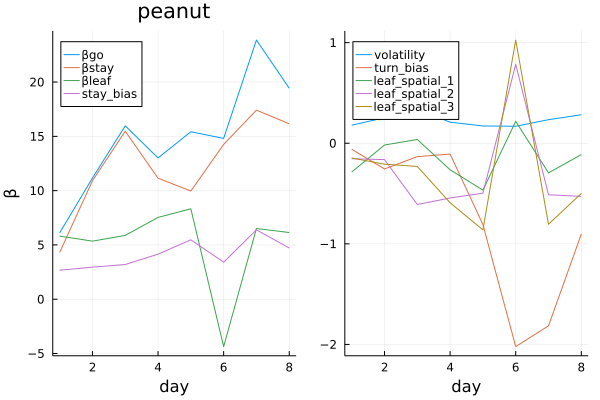

In [14]:
animal = "peanut"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

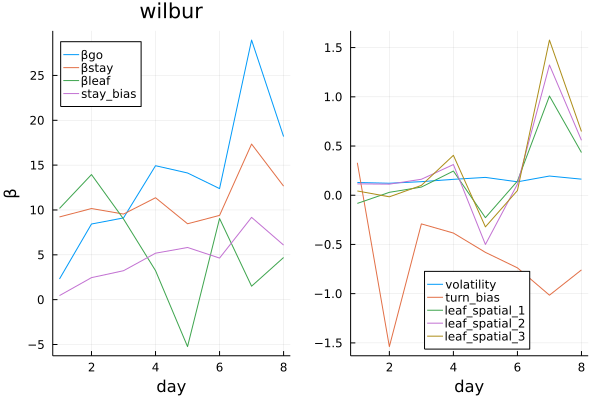

In [15]:
animal = "wilbur"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=(0.4, 0.22))
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

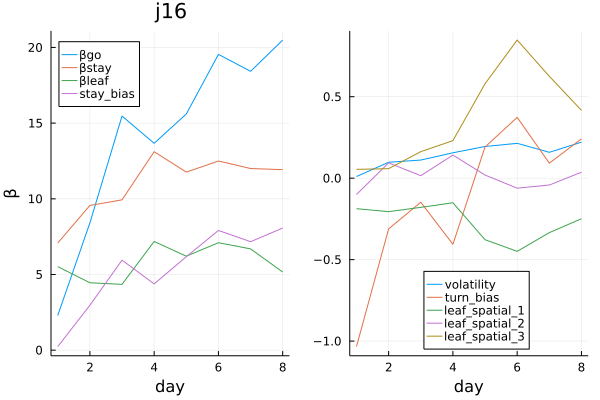

In [16]:
animal = "j16"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=(0.4, 0.22))
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

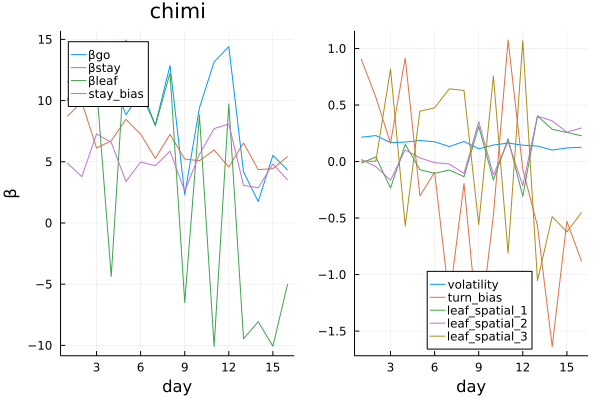

In [17]:
animal = "chimi"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=(0.4, 0.22))
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

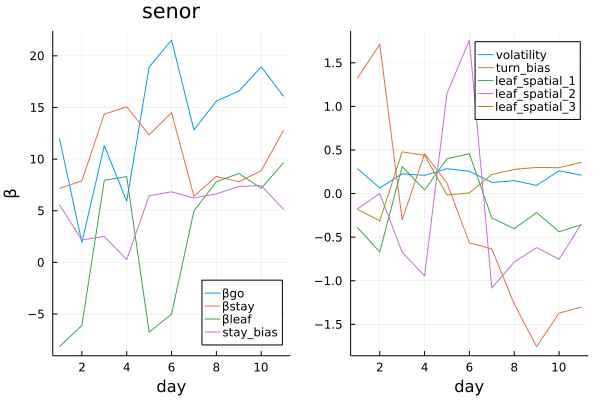

In [18]:
animal = "senor"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=:bottomright)
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=:topright)
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

# State Entropy

One simple measure of uncertainty is entropy of the belief state, $\alpha$.

$\text{state entropy} = -\sum_i \alpha_i \log(\alpha_i)$

On each trial, we have a distribution of weights across the possible contingencies.
- In a low-entropy situation, this is centered on a small number of contingencies - most values in $\alpha$ are near-zero, and a few are very high.
- In a high-entropy situation, our belief state is diffuse - at an extreme, we give equal weight to all possible contingencies

Below, we're plotting the state entropy for each rat, averaged over days/sessions.
- We expect high entropy at the start of a session, and at each contingency switch

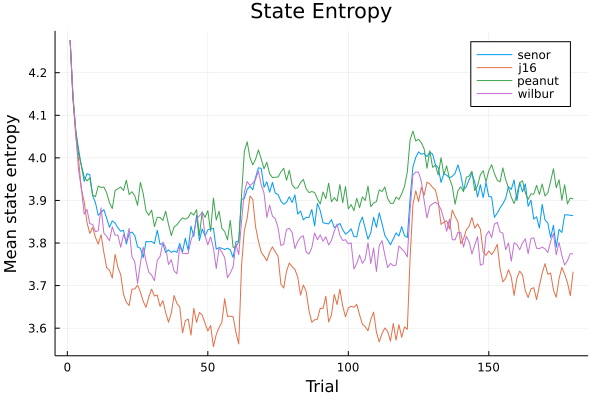

In [19]:
p = plot()
for animal in animals[[1,3,4,5]]
    df = Qs[animal]
    plot!(combine(groupby(df, :trial), :state_entropy=>mean=>:state_entropy)[1:180,:state_entropy], label=animal)
end
p
ylabel!("Mean state entropy")
xlabel!("Trial")
title!("State Entropy")

## Reward Entropy

A closely related approach is to calculate the entropy of reward belief at each leaf

Given a belief state $\alpha$, and reward probabilities $\phi$, each leaf has a marginal reward distribution
$[p_1, p_2, p_3]$ where $p_1 = p(r=0.2), p_2 = p(r=0.5), p_3 = p(r=0.8)$

Then for each leaf, $\text{reward entropy}_\text{leaf j} = -\sum_i p_i \log(p_i)$

We them sum these across all six leaves for each trial.

Reward entropy is plotted here. This measure is *very* similar to the state entropy

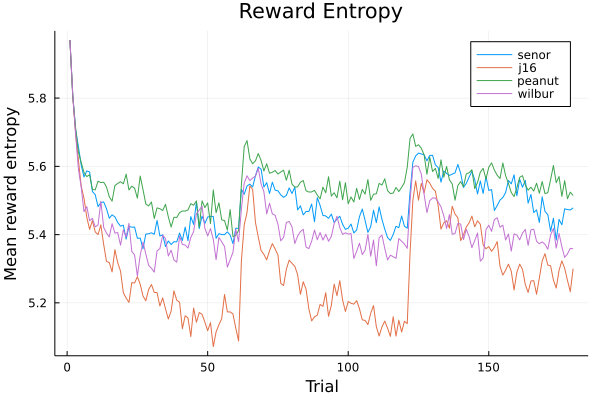

In [20]:
p = plot()
for animal in animals[[1,3,4,5]]
    df = Qs[animal]
    plot!(combine(groupby(df, :trial), :reward_entropy=>mean=>:reward_entropy)[1:180,:reward_entropy], label=animal)
end
p
ylabel!("Mean reward entropy")
xlabel!("Trial")
title!("Reward Entropy")

## Stem Choice Probability Variance

On each trial, our stem choice, after pushing the Q-values through a softmax, gives us three choice probabilities:

$p_1 \approx e^{\beta_1 Q_1} / (e^{\beta_1 Q_1} + e^{\beta_2 Q_2} + e^{\beta_3 Q_3})$

$p_2 \approx e^{\beta_2 Q_2} / (e^{\beta_1 Q_1} + e^{\beta_2 Q_2} + e^{\beta_3 Q_3})$

$p_3 \approx e^{\beta_3 Q_3} / (e^{\beta_1 Q_1} + e^{\beta_2 Q_2} + e^{\beta_3 Q_3})$

Each of these values is based on the marginal expected reward of that stem.

However, backing up a step, $\alpha$ together with $\phi$ gives us a probability that each leaf has return 0.2, 0.5, or 0.8 (this is the same idea as the reward entropy).

For each possibility for each leaf, 3^6 configurations, we can find the choice probability of each stem, and combining that with our belief of the probability of that configuration, we get a distribution over stem choice probability. (Note that the mean of this distribution isn't quite the choice probability given the mean expected values, given the nonlinearity of the softmax)

We can then find the variance of each of those probabilities, giving us a measure of uncertainty about our stem decision

Below is the mean uncertainty of the chosen stem (though alternatively we might be interested in the previous stem)

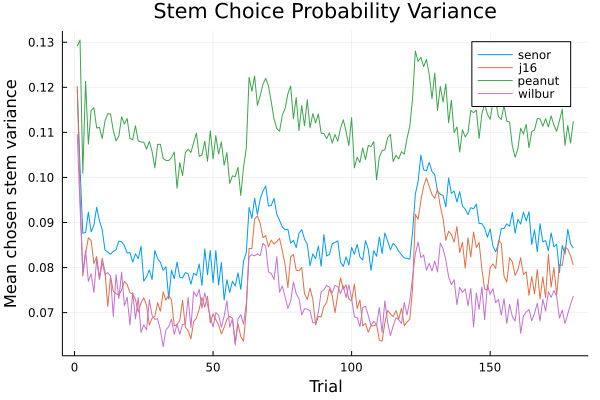

In [21]:
p = plot()
for animal in animals[[1,3,4,5]]
    df = Qs[animal]
    plot!(combine(groupby(df, :trial), :stem_choice_var=>mean=>:stem_choice_var)[1:180,:stem_choice_var], label=animal)
end
p
ylabel!("Mean chosen stem variance")
xlabel!("Trial")
title!("Stem Choice Probability Variance")

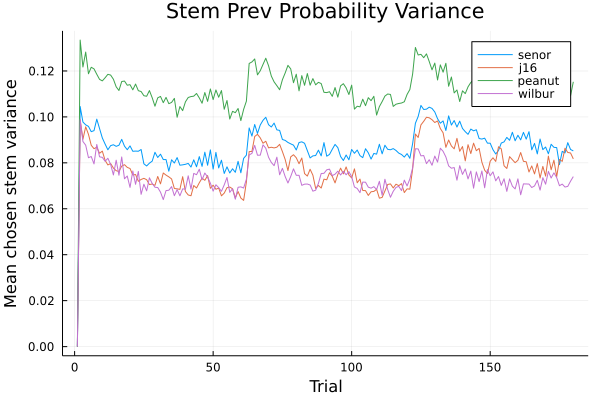

In [22]:
p = plot()
for animal in animals[[1,3,4,5]]
    df = Qs[animal]
    plot!(combine(groupby(df, :trial), :stem_stay_var=>mean=>:stem_stay_var)[1:180,:stem_stay_var], label=animal)
end
p
ylabel!("Mean chosen stem variance")
xlabel!("Trial")
title!("Stem Prev Probability Variance")

We can also directly visualize the mean probability of the chosen stem, shown below

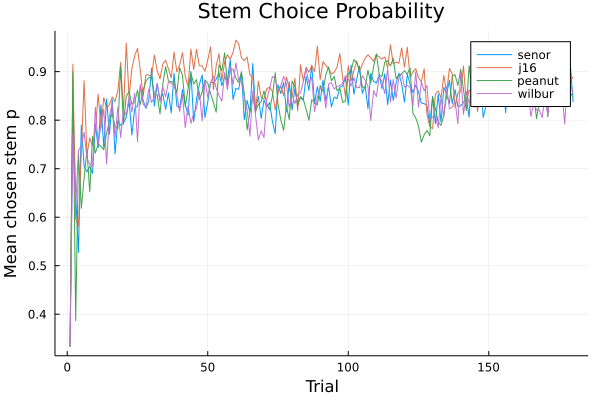

In [23]:
p = plot()
for animal in animals[[1,3,4,5]]
    df = Qs[animal]
    plot!(combine(groupby(df, :trial), :stem_choice_p=>mean=>:stem_choice_p)[1:180,:stem_choice_p], label=animal)
end
p
ylabel!("Mean chosen stem p")
xlabel!("Trial")
title!("Stem Choice Probability")

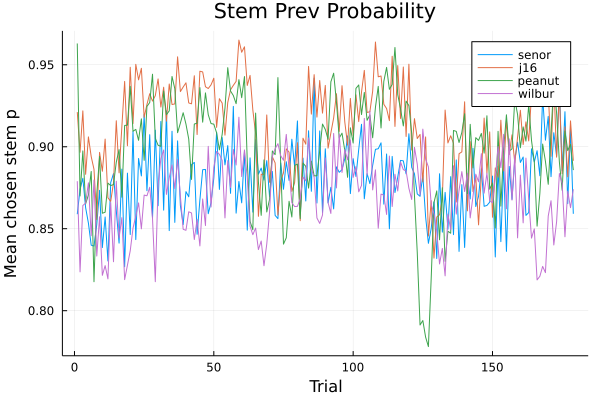

In [24]:
p = plot()
for animal in animals[[1,3,4,5]]
    df = Qs[animal]
    plot!(combine(groupby(df, :trial), :stem_stay_p=>mean=>:stem_stay_p)[2:180,:stem_stay_p], label=animal)
end
p
ylabel!("Mean chosen stem p")
xlabel!("Trial")
title!("Stem Prev Probability")

# Prediction Accuracy

How well are we predicting a stem switch?

Below, we look at trials where a stem switch happened, and if so, if we attribute more weight to the stem that was actually chosen

In [25]:
for animal in animals
    data = Qs[animal]
    preds = []
    for i in 2:length(data)
        if data.stemswitch[i]
            prevstem = data.stemchoice[i-1]
            if prevstem == 1
                if data.stemchoice[i] == 2
                    push!(preds, data.stem_1_p[i] > data.stem_3_p[i])
                else
                    push!(preds, data.stem_3_p[i] > data.stem_2_p[i])
                end
            elseif prevstem == 2
                if data.stemchoice[i] == 3
                    push!(preds, data.stem_3_p[i] > data.stem_1_p[i])
                else
                    push!(preds, data.stem_1_p[i] > data.stem_3_p[i])
                end
            else
                if data.stemchoice[i] == 1
                    push!(preds, data.stem_1_p[i] > data.stem_2_p[i])
                else
                    push!(preds, data.stem_2_p[i] > data.stem_1_p[i])
                end
            end
        end
    end
    println(animal, ": ", round(mean(preds); digits=3))
end

senor: 0.723
chimi: 0.708
j16: 0.642
peanut: 0.756
wilbur: 0.7


How frequently do we predict a stem switch at all?

A couple ways to look at this.
1. How frequently do we predict less than 50% chance of staying at the current stem?

In [26]:
println("Fraction of trials predicting a stem switch")
for animal in animals
    data = Qs[animal]
    preds = []
    for i in 2:length(data)
        prevstem = data.stemchoice[i-1]
        if prevstem == 1
            push!(preds, data.stem_1_p[i] < 0.5)
        elseif prevstem == 2
            push!(preds, data.stem_2_p[i] < 0.5)
        else
            push!(preds, data.stem_3_p[i] < 0.5)
        end
    end
    println(animal, ": ", round(mean(preds); digits=10))
end

Fraction of trials predicting a stem switch
senor: 0.1257899488
chimi: 0.0108760134
j16: 0.0767419038
peanut: 0.0668717135
wilbur: 0.1221697659


2. How often is either of the other two stems individually more likely?

In [27]:
println("Fraction of trials predicting another stem")
for animal in animals
    data = Qs[animal]
    preds = []
    for i in 2:length(data)
        prevstem = data.stemchoice[i-1]
        if prevstem == 1
            push!(preds, (data.stem_1_p[i] < data.stem_3_p[i]) | (data.stem_1_p[i] < data.stem_2_p[i]))
        elseif prevstem == 2
            push!(preds, (data.stem_2_p[i] < data.stem_3_p[i]) | (data.stem_2_p[i] < data.stem_1_p[i]))
        else
            push!(preds, (data.stem_3_p[i] < data.stem_2_p[i]) | (data.stem_3_p[i] < data.stem_1_p[i]))
        end
    end
    println(animal, ": ", round(mean(preds); digits=10))
end

Fraction of trials predicting another stem
senor: 0.1156334637
chimi: 0.0041526597
j16: 0.0639842983
peanut: 0.0465323941
wilbur: 0.1055978418


Basically never.

What about on trials where a stem switch actually happens?

In [28]:
println("Fraction of trials predicting a stem switch, on trials where a stem switch happened")
for animal in animals
    data = Qs[animal]
    preds = []
    for i in 2:length(data)
        if data.stemswitch[i]
            prevstem = data.stemchoice[i-1]
            if prevstem == 1
                push!(preds, data.stem_1_p[i] < 0.5)
            elseif prevstem == 2
                push!(preds, data.stem_2_p[i] < 0.5)
            else
                push!(preds, data.stem_3_p[i] < 0.5)
            end
        end
    end
    println(animal, ": ", round(mean(preds); digits=10))
end

Fraction of trials predicting a stem switch, on trials where a stem switch happened
senor: 0.2586206897
chimi: 0.0365296804
j16: 0.2756849315
peanut: 0.2339544513
wilbur: 0.3167701863


In [29]:
println("Fraction of trials predicting another stem, on trials where a stem switch happened")
for animal in animals
    data = Qs[animal]
    preds = []
    for i in 2:length(data)
        if data.stemswitch[i]
            prevstem = data.stemchoice[i-1]
            if prevstem == 1
                push!(preds, (data.stem_1_p[i] < data.stem_3_p[i]) | (data.stem_1_p[i] < data.stem_2_p[i]))
            elseif prevstem == 2
                push!(preds, (data.stem_2_p[i] < data.stem_3_p[i]) | (data.stem_2_p[i] < data.stem_1_p[i]))
            else
                push!(preds, (data.stem_3_p[i] < data.stem_2_p[i]) | (data.stem_3_p[i] < data.stem_1_p[i]))
            end
        end
    end
    println(animal, ": ", round(mean(preds); digits=10))
end

Fraction of trials predicting another stem, on trials where a stem switch happened
senor: 0.2524630542
chimi: 0.0114155251
j16: 0.2585616438
peanut: 0.1739130435
wilbur: 0.298136646


Actually never.

## Similar analysis for leaves

todo